B.8. Implement  KNN,  Naïve  Bayes,  and  SVM  classifiers  using  Python-based  ML  tools  for 
comparison of their performance on the review sentiment classification dataset.  
 

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import List
import re
from collections import Counter
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Convert TF-IDF dictionaries to vectors
from sklearn.feature_extraction import DictVectorizer

#this is just to get data for SVM
from sklearn.datasets import make_blobs

import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/rito/.cache/kagglehub/datasets/abhi8923shriv/sentiment-analysis-dataset/versions/9


$\textbf{KNN}$

Kth nearest neighbors(KNN) does not require any training In a way the dataset itself is the model. we are going to use the dataset itself and the nearest neighbors the predict which cluster out data belong to by calculating the euclidean distance from out point to the nearest points.   

formula for euclidean distance on n dimensions are given below: 

The Euclidean distance in n-dimensions is the straight-line distance between two points, generalized from the Pythagorean theorem: it's the square root of the sum of the squared differences between their corresponding coordinates across all n dimensions. For points $(P_{1}(x_{1},x_{2},\dots ,x_{n})) and (P_{2}(y_{1},y_{2},\dots ,y_{n})·)$, the formula is

$d(p_1,p_2)=\sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$

Formula

Points: $(P_{1}=(x_{1},x_{2},\dots ,x_{n})) and (P_{2}=(y_{1},y_{2},\dots ,y_{n}))$.

Distance: $(d(P_{1},P_{2})=\sqrt{(x_{1}-y_{1})^{2}+(x_{2}-y_{2})^{2}+\dots +(x_{n}-y_{n})^{2}})$

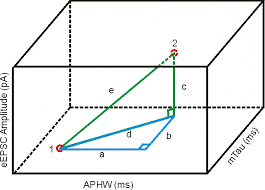

In [89]:
path = path + "/train.csv"
data = pd.read_csv(path, encoding='latin1')
df = pd.DataFrame(data)

In [90]:
sentiment_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['sentiment_label'] = df['sentiment'].map(sentiment_map)

In [91]:
time_map = {
    'morning': [1,0,0],
    'noon': [0,1,0],
    'night': [0,0,1]
}

df['time_label'] = df['Time of Tweet'].map(time_map)

In [92]:
def tokenize(text):
    if not isinstance(text, str):
        return []   # ignore NaN or non-string values
    cleaned_text = re.sub(r"[^\w\s]", "", text)
    return cleaned_text.lower().split()


In [93]:
vocal_class = set()

for i in range(1, len(df['sentiment'])):
    d1 = tokenize(df.loc[i,'text'])
    d2 = tokenize(df.loc[i-1,'text'])

    vocal_class = vocal_class.union(d1,d2)

In [94]:
def compute_tf(tokens):
    if not tokens:
        return {}
    tf = Counter(tokens)
    total = len(tokens)
    return {word: count / total for word, count in tf.items()}

In [95]:
df_count = dict.fromkeys(vocal_class, 0)

for text in df['text']:
    tokens = set(tokenize(text))  # IMPORTANT: set()
    for word in tokens:
        df_count[word] += 1

In [96]:
N = len(df['text'])

idf = {}
for word, df_val in df_count.items():
    idf[word] = np.log((N + 1) / (df_val + 1)) + 1


In [97]:
def compute_tfidf(tf, idf):
    return {word: tf[word] * idf.get(word, 0) for word in tf}

In [98]:
tf_idf = []

def compute_text_tfidf(text):
    tokens = tokenize(text)
    tf = compute_tf(tokens)
    return compute_tfidf(tf, idf)


In [99]:
df['text_tf_idf'] = df['text'].apply(compute_text_tfidf)

In [100]:
df['text_tf_idf']

0        {'id': 0.8789117602387839, 'have': 0.487740461...
1        {'sooo': 0.6529938641662576, 'sad': 0.50814019...
2        {'my': 0.5455952545877629, 'boss': 1.626048814...
3        {'what': 0.8848925611233729, 'interview': 1.58...
4        {'sons': 0.6941586112735001, 'of': 0.249962338...
                               ...                        
27476    {'wish': 0.31304252675876254, 'we': 0.28724338...
27477    {'ive': 0.22859596435970753, 'wondered': 0.457...
27478    {'yay': 0.28040798717268334, 'good': 0.1865769...
27479    {'but': 0.7007870503412782, 'it': 1.2153791252...
27480    {'all': 0.38772136733186535, 'this': 0.3912074...
Name: text_tf_idf, Length: 27481, dtype: object

In [101]:
vectorizer = DictVectorizer(sparse=False)
X_all = vectorizer.fit_transform(df['text_tf_idf'].tolist())
y_all = df['sentiment_label'].values

In [102]:
# Use only a sample of your data
sample_size = 5000  # Adjust based on your PC's RAM
df_sample = df.sample(n=sample_size, random_state=42)

# Then convert to vectors
vectorizer = DictVectorizer(sparse=False)
X_sample = vectorizer.fit_transform(df_sample['text_tf_idf'].tolist())
y_sample = df_sample['sentiment_label'].values

# Now split - this should work
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

In [103]:
def euclidean_dist(p,q):
    return np.sqrt(np.sum((np.array(p) - np.array(q))**2))

In [104]:
# 4. Modify your KNN class to work with the data format
class KNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X_train, y_train):
        """Store training data"""
        self.X_train = X_train
        self.y_train = y_train
    
    def predict(self, X_test):
        """Predict labels for test data"""
        predictions = []
        
        for test_point in X_test:
            # Calculate distances to all training points
            distances = []
            for i, train_point in enumerate(self.X_train):
                distance = euclidean_dist(train_point, test_point)
                distances.append((distance, self.y_train[i]))
            
            # Sort by distance and get k nearest neighbors
            distances.sort(key=lambda x: x[0])
            k_nearest = distances[:self.k]
            
            # Get the most common label
            k_labels = [label for _, label in k_nearest]
            prediction = Counter(k_labels).most_common(1)[0][0]
            predictions.append(prediction)
        
        return np.array(predictions)


In [105]:
k = KNN(k=5)
k.fit(X_train,y_train)
y_prid = k.predict(X_test)

In [112]:
acc_knn = accuracy_score(y_test, y_prid)
precision_knn = precision_score(y_test, y_prid, average='weighted')
recall_knn = recall_score(y_test, y_prid, average='weighted')
f1_knn = f1_score(y_test, y_prid, average='weighted')

print(f"Accuracy: {acc_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_prid, target_names=['negative', 'neutral', 'positive']))

Accuracy: 0.4290
Precision: 0.4290
Recall: 0.4290
F1-Score: 0.4277

Classification Report:
              precision    recall  f1-score   support

    negative       0.43      0.39      0.41       283
     neutral       0.43      0.49      0.46       409
    positive       0.43      0.39      0.41       308

    accuracy                           0.43      1000
   macro avg       0.43      0.42      0.42      1000
weighted avg       0.43      0.43      0.43      1000



In [114]:
from sklearn.naive_bayes import MultinomialNB

# Note: MultinomialNB requires non-negative values
# If your TF-IDF has negative values, use GaussianNB instead
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)
y_pred_nb = nb_classifier.predict(X_test)

# Calculate metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy: {acc_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, 
                          target_names=['Negative', 'Neutral', 'Positive']))

Accuracy: 0.5570
Precision: 0.5675
Recall: 0.5570
F1-Score: 0.5560

Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.43      0.48       283
     Neutral       0.51      0.64      0.57       409
    Positive       0.68      0.56      0.61       308

    accuracy                           0.56      1000
   macro avg       0.57      0.54      0.55      1000
weighted avg       0.57      0.56      0.56      1000



In [115]:
from sklearn.svm import SVC

svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)
svm_classifier.fit(X_train, y_train)
y_pred_svm = svm_classifier.predict(X_test)

# Calculate metrics
acc_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print(f"Accuracy: {acc_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, 
                          target_names=['Negative', 'Neutral', 'Positive']))

Accuracy: 0.5790
Precision: 0.5814
Recall: 0.5790
F1-Score: 0.5800

Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.54      0.53       283
     Neutral       0.55      0.55      0.55       409
    Positive       0.69      0.65      0.67       308

    accuracy                           0.58      1000
   macro avg       0.58      0.58      0.58      1000
weighted avg       0.58      0.58      0.58      1000



In [116]:
print("\n" + "="*50)
print("PERFORMANCE COMPARISON")
print("="*50)

comparison_df = pd.DataFrame({
    'Classifier': ['KNN', 'Naive Bayes', 'SVM'],
    'Accuracy': [acc_knn, acc_nb, acc_svm],
    'Precision': [precision_knn, precision_nb, precision_svm],
    'Recall': [recall_knn, recall_nb, recall_svm],
    'F1-Score': [f1_knn, f1_nb, f1_svm]
})

print(comparison_df.to_string(index=False))

# Find best classifier
best_idx = comparison_df['Accuracy'].idxmax()
best_classifier = comparison_df.loc[best_idx, 'Classifier']
best_accuracy = comparison_df.loc[best_idx, 'Accuracy']
print(f"\nBest Classifier: {best_classifier} with Accuracy: {best_accuracy:.4f}")


PERFORMANCE COMPARISON
 Classifier  Accuracy  Precision  Recall  F1-Score
        KNN     0.429   0.429048   0.429  0.427688
Naive Bayes     0.557   0.567504   0.557  0.555987
        SVM     0.579   0.581428   0.579  0.580018

Best Classifier: SVM with Accuracy: 0.5790


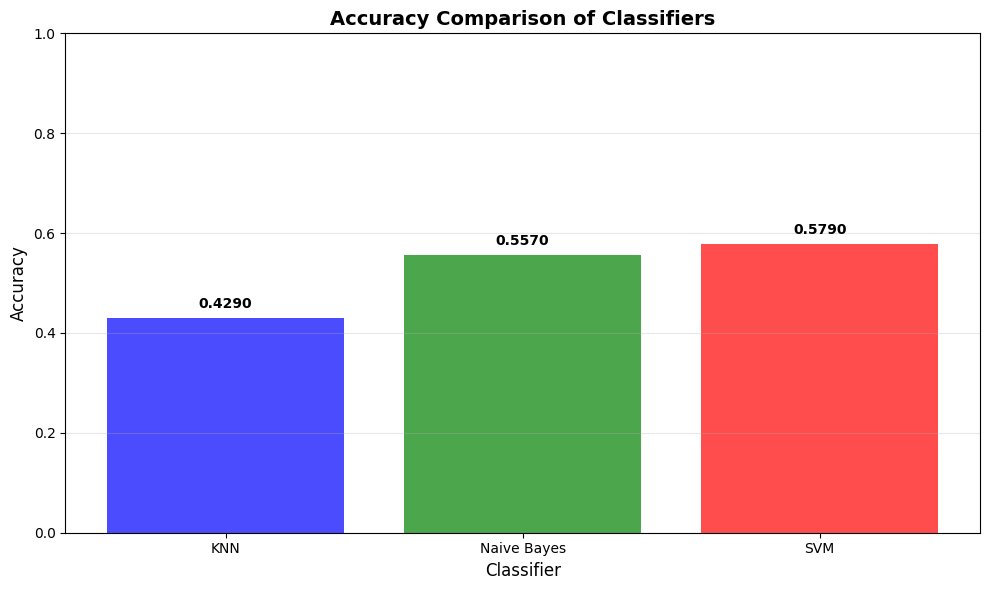

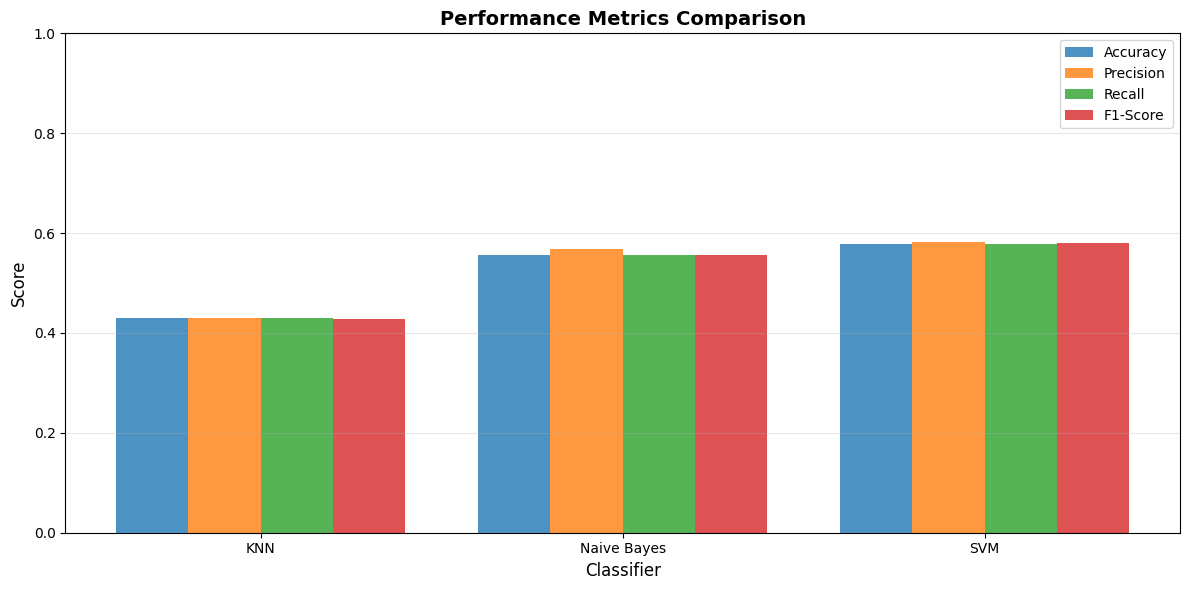

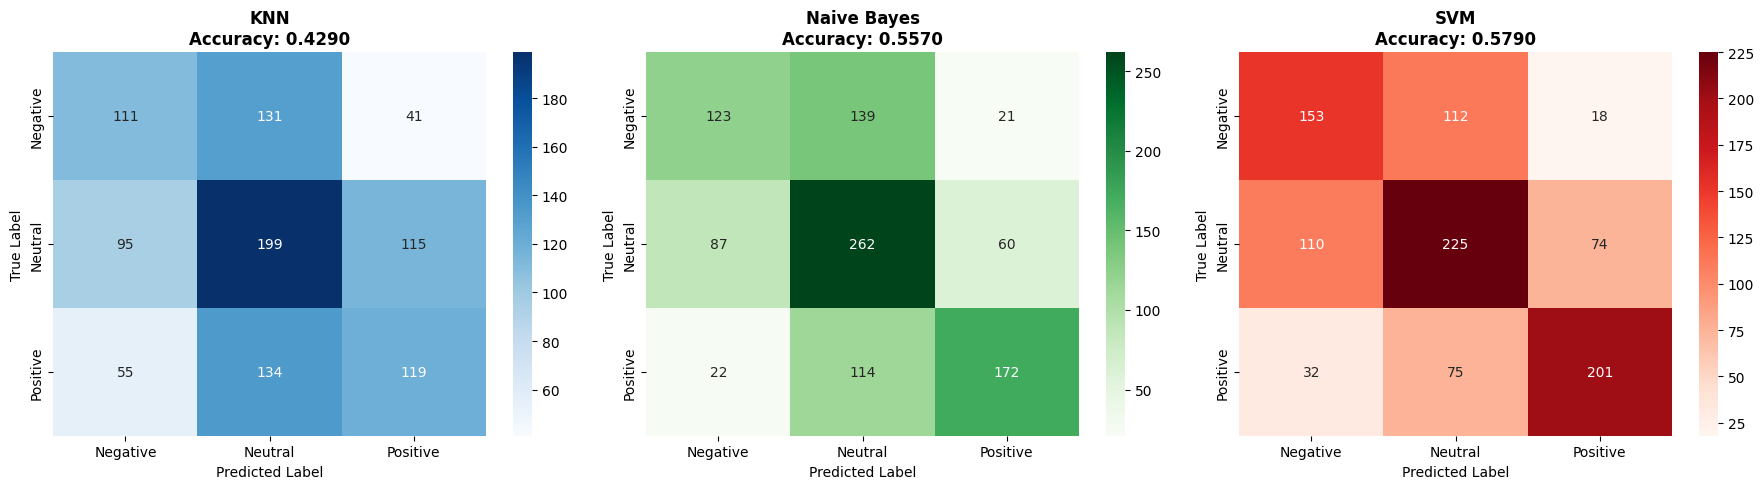


TESTING WITH NEW EXAMPLES

Review: 'This product is absolutely amazing! I love it!'
  KNN Prediction: Positive
  Naive Bayes Prediction: Positive
  SVM Prediction: Positive

Review: 'Terrible experience, waste of money.'
  KNN Prediction: Neutral
  Naive Bayes Prediction: Negative
  SVM Prediction: Neutral

Review: 'It's okay, nothing special.'
  KNN Prediction: Neutral
  Naive Bayes Prediction: Positive
  SVM Prediction: Positive


In [119]:
# Plot 1: Accuracy Comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Classifier'], comparison_df['Accuracy'], 
        color=['blue', 'green', 'red'], alpha=0.7)
plt.xlabel('Classifier', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy Comparison of Classifiers', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: All Metrics Comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Classifier']))
width = 0.2

bars1 = ax.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Classifier', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Classifier'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

# Plot 3: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_prid)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
axes[0].set_title(f'KNN\nAccuracy: {acc_knn:.4f}', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
axes[1].set_title(f'Naive Bayes\nAccuracy: {acc_nb:.4f}', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
axes[2].set_title(f'SVM\nAccuracy: {acc_svm:.4f}', fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ============================================
# 6. TEST WITH NEW EXAMPLES (Optional)
# ============================================
print("\n" + "="*50)
print("TESTING WITH NEW EXAMPLES")
print("="*50)

# Example reviews
test_reviews = [
    "This product is absolutely amazing! I love it!",
    "Terrible experience, waste of money.",
    "It's okay, nothing special."
]

for review in test_reviews:
    # Convert to TF-IDF
    review_tfidf = compute_text_tfidf(review)
    review_vector = vectorizer.transform([review_tfidf])
    
    # Predict with all classifiers
    pred_knn = k.predict(review_vector)[0]
    pred_nb = nb_classifier.predict(review_vector)[0]
    pred_svm = svm_classifier.predict(review_vector)[0]
    
    sentiment_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    
    print(f"\nReview: '{review}'")
    print(f"  KNN Prediction: {sentiment_names[pred_knn]}")
    print(f"  Naive Bayes Prediction: {sentiment_names[pred_nb]}")
    print(f"  SVM Prediction: {sentiment_names[pred_svm]}")